# Electricidad y Magnetismo
Vamos a estar trabajando con las ecuaciones del vacío. Tenemos un potenial eléctrico $U(\vec{r})$ generado por una densidad de carga $\rho(\vec{r})$ y satisface la ecuación:
\begin{equation}
\nabla^2 U(\vec{r}) = -\frac{\rho(\vec{r})}{\epsilon_0}
\end{equation}
Para el caso donde la densidad de carga sea nula, obtenemos el caso de la **Ecuación de Laplace**. Para 2D, tenemos una ecuación diferencial parcial:
\begin{equation}
\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} = -\frac{\rho(x,y)}{\epsilon_0}
\end{equation}
Si discretizamos la ecuación de Laplace:
\begin{equation}
U_{i+1,j} + U_{i-1,j} - 2U_{i,j} + U_{i,j+1}+U_{i,j-1}-2U_{i,j} = 0
\end{equation}
$$U_{i,j} = \frac{U_{i+1,j} + U_{i-1,j} + U_{i,j+1}+U_{i,j-1}}{4}+\frac{\Delta x^2\rho_{i,j}}{4\epsilon_0}$$
La interpretación es que el potencial en un punto es el promediado del valor de sus 4 vecinos más una contribución dada por la densidad de carga.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Método de Jacobi
Actualizamos todos los puntos simultáneamente, usa únicamente valores de la iteración anterior, y conserva mejor la simetría del problema:
$$U_{i,j}^{n+1} = \frac{1}{4}\left(U^n_{i+1,j} + U^n_{i-1,j} + U^n_{i,j+1}+U^n_{i,j-1}\right)$$
# Método de Gauss - Seidel
Usa los valores recién calculados, converge más rápido pero puede romper ciertas simetrías numéricas:
$$U_{i,j}^{n+1} = \frac{1}{4}\left(U^{n+1}_{i+1,j} + U^{n+1}_{i-1,j} + U^{n+1}_{i,j+1}+U^{n+1}_{i,j-1}\right)$$


Problema:
## Potencial eléctrico sobre una región cuadrada libre de carga:
- Su frontera superior se mantiene a 100V
- Sus lados y parte inferior se encuentran aterrizados (0V)

In [ ]:
Nx = 50
Ny = 50

h = 0.1
tol = 1e-4
max_iterations = int(1e4)
V01 = 100
V02 = 0

u = np.zeros((Nx, Ny))
#Extremo superior
u[:,Ny - 1] = V01
#Extremos laterales e inferior
u[0, 1:] = V02
u[Nx - 1, 1:] = V02
u[1:-2, 0]  = V02

for iteration in range(max_iterations):
    unew = u.copy()
    for i in range(1, Nx - 1):
        for j in range(1, Ny - 1):
            unew[i, j] = (u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1]) / 4
    
        error = np.max(np.abs(unew - u))
        if iteration % 100 == 0:
            print('Iteración: ', iteration, 'Error: ', error)
    u = unew.copy()
    #if error < 1e-4:
    #    print('Convergencia alcanzada')
    #    break    
    


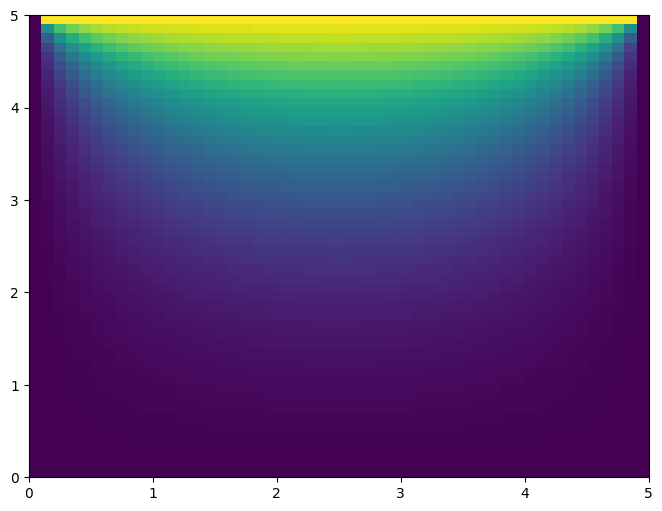

In [8]:
#malla
x = np.arange(0, Nx) * h
y = np.arange(0, Ny) * h

X, Y = np.meshgrid(x, y)
plt.figure(figsize=(8,6))
plt.imshow(
            u.T,
            origin = 'lower',
            extent = [0, Nx * h, 0, Ny * h],
            aspect = 'auto'
)
plt.show()

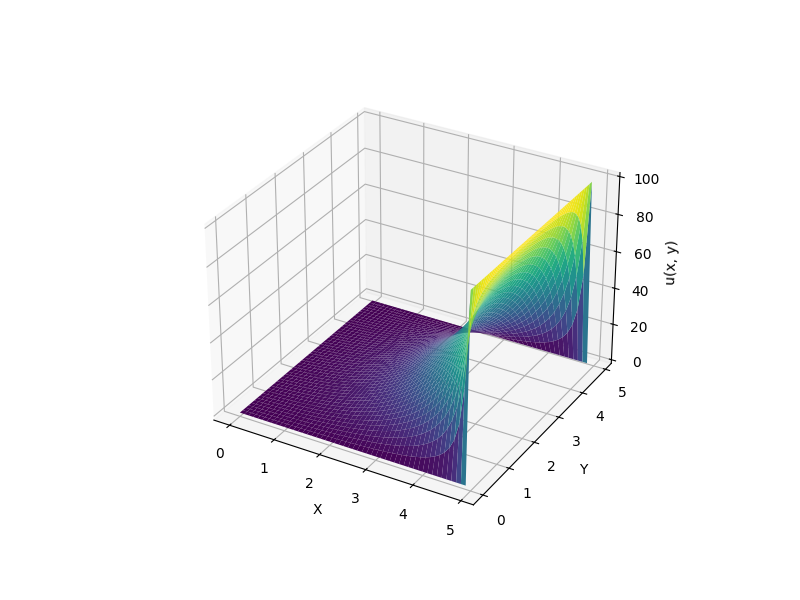

In [11]:
from mpl_toolkits.mplot3d import Axes3D
x = np.arange(0, Nx, 1) * h
y = np.arange(0, Ny, 1) * h

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot(111, projection = '3d')
ax.plot_surface(X, Y, u, cmap = 'viridis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('u(x, y)')

plt.show()

# Convergencia
Es posible monitorear el error máximo:
$$e = máx|U^{(n+1)} - U^{(n)}|$$